In [ ]:
# Install necessary packages
%pip install matplotlib networkx pyvis

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
from yafs.topology import Topology

# Import the function from the local script
# Ensure the notebook is running in the same directory as felipe_tutorial1.py
from felipe_tutorial1 import createRandomTopology

In [3]:
# Generate the topology
topo_dict = createRandomTopology(
    num_fog_nodes=2,
    middle_per_fog=2,       # Reduced for clearer visualization
    routers_per_middle=2,   # Reduced for clearer visualization
    sensors_per_router=1,
    actuators_per_router=1,
    random_seed=42
)

# Load into YAFS Topology object to convert to NetworkX graph
t = Topology()
t.load(topo_dict)
G = t.G

print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

Nodes: 31
Edges: 30


C:\Users\Specm\AppData\Roaming\Python\Python314\site-packages\IPython\core\interactiveshell.py:3123: FutureWarning: The load function will merged with load_all_node_attr function
  result = self._run_cell(


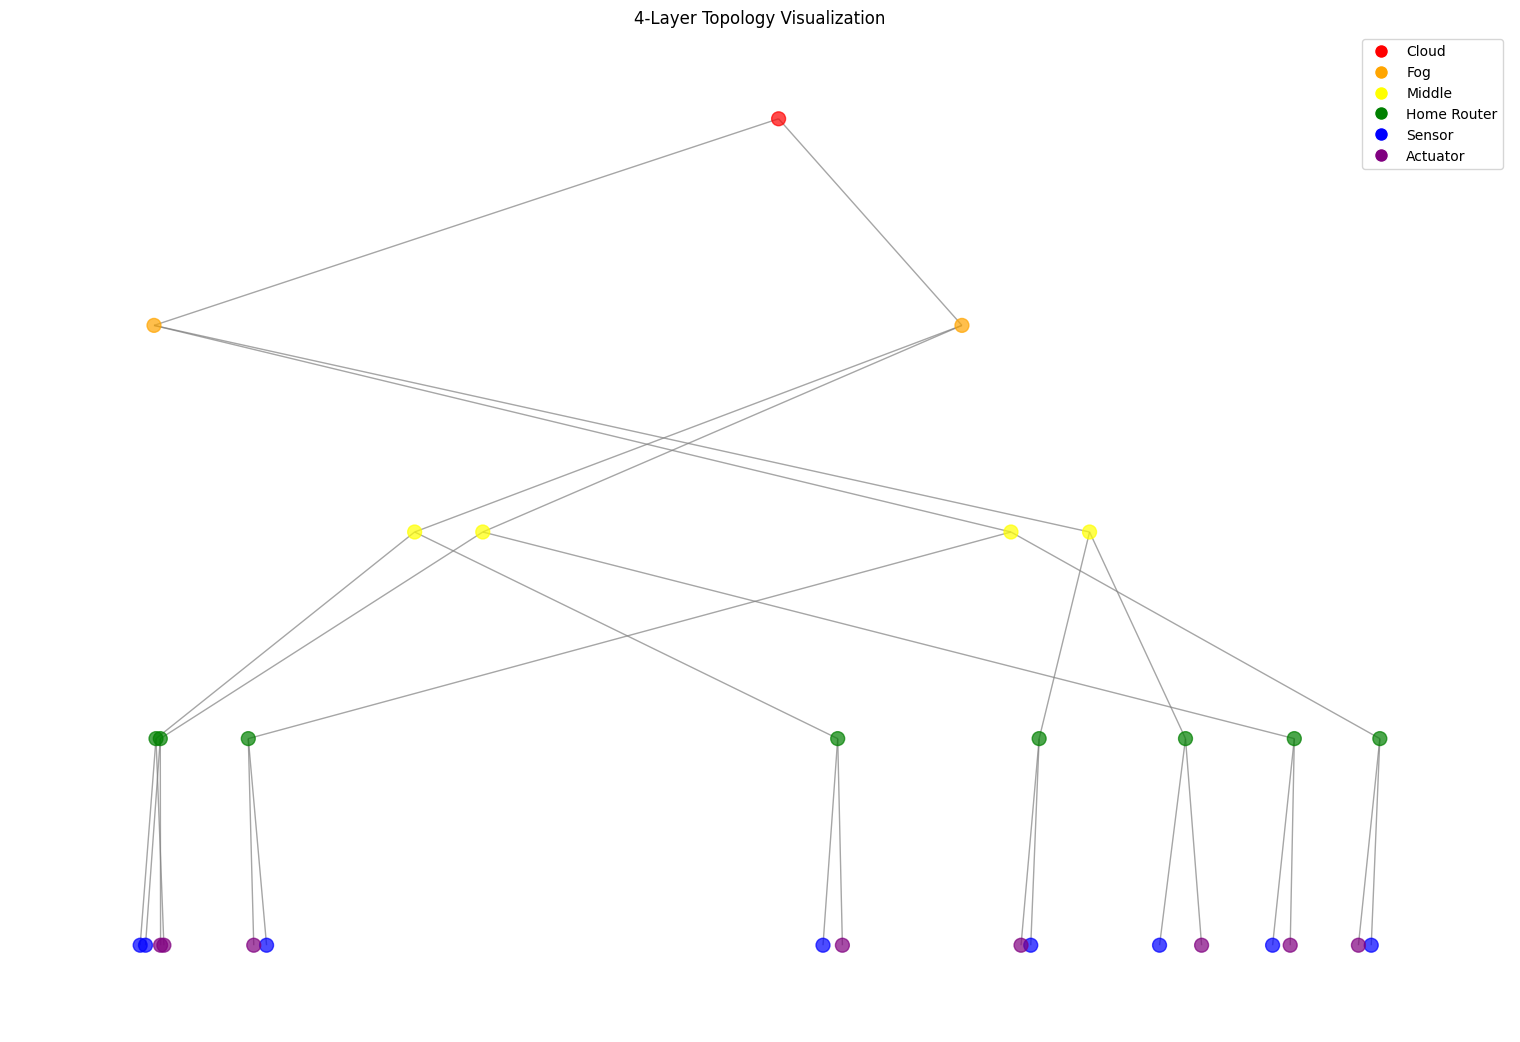

In [ ]:
from pyvis.network import Network

# Create a PyVis network
# notebook=True enables Jupyter support
# cdn_resources='in_line' ensures it works without internet if needed, and in VS Code
net = Network(notebook=True, height="750px", width="100%", cdn_resources='in_line')

# Add nodes with specific colors based on their model/layer
for n in G.nodes():
    # Get model from graph node or fallback to topo_dict
    model = G.nodes[n].get('model', '')
    if not model:
         for entity in topo_dict['entity']:
             if entity['id'] == n:
                 model = entity['model']
                 break
    
    color = '#808080' # Default Grey
    label = str(n)
    title = f"ID: {n}\nModel: {model}" # Tooltip

    if 'cloud' in model:
        color = '#FF0000' # Red
        label = "Cloud"
    elif 'fog' in model:
        color = '#FFA500' # Orange
        label = "Fog"
    elif 'middle' in model:
        color = '#FFFF00' # Yellow
        label = "Middle"
    elif 'home-router' in model:
        color = '#008000' # Green
        label = "Router"
    elif 'sensor' in model:
        color = '#0000FF' # Blue
        label = "Sensor"
    elif 'actuator' in model:
        color = '#800080' # Purple
        label = "Actuator"

    # Add node without fixed coordinates (dynamic physics layout)
    net.add_node(n, label=label, title=title, color=color)

# Add edges
for s, d in G.edges():
    net.add_edge(s, d)

# Enable physics controls to play with the layout
net.show_buttons(filter_=['physics'])

# Display the graph
net.show("topology.html")